<h1 style='color:#5BC0EB'>PTB-XL — Exploración y carga de datos</h1>
<p style='color:#b0b0b0'>Primer contacto con el dataset. Cargamos señales ECG a 100 Hz y 500 Hz, exploramos los metadatos clínicos y visualizamos la diferencia de resolución que motiva el proyecto de reconstrucción.</p>

<h2 style='color:#5BC0EB'>1. Instalación de dependencias</h2>
<p style='color:#b0b0b0'>Solo necesitamos ejecutar esto una vez. <code>wfdb</code> es la librería oficial para leer formatos de PhysioNet.</p>

In [5]:
# Instalar dependencias del proyecto
# wfdb: lectura de archivos en formato PhysioNet (.hea + .dat)
# El resto ya viene con Anaconda/miniconda
%pip install wfdb --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h2 style='color:#5BC0EB'>2. Descarga del dataset</h2>
<p style='color:#b0b0b0'>PTB-XL está alojado en PhysioNet y no requiere registro. El dataset completo pesa ~3 GB, así que por ahora descargamos los primeros 500 registros de cada resolución más el CSV de metadatos.</p>
<blockquote style='border-left:4px solid #5BC0EB; background:rgba(91,192,235,0.08); color:#A8D8EA; padding:10px 14px; margin:8px 0'>
<strong>Estructura del dataset:</strong> cada registro existe en dos versiones sincronizadas — <code>records100/</code> (100 Hz, 1000 muestras por registro de 10 s) y <code>records500/</code> (500 Hz, 5000 muestras). Ambas versiones del mismo <code>ecg_id</code> son el mismo paciente, mismo momento, mismo electrodo. Eso es exactamente el par entrada/ground truth que necesitamos.
</blockquote>

In [6]:
import wfdb
import os
import urllib.request

DATA_DIR = 'ptbxl_data'
os.makedirs(DATA_DIR, exist_ok=True)

# /content/ es la página HTML del dataset — los archivos descargables están en /files/
BASE_URL = 'https://physionet.org/files/ptb-xl/1.0.3/'

def download_file(remote_path, local_dir):
    """Descarga un archivo de PhysioNet si no existe localmente."""
    url = BASE_URL + remote_path
    dest = os.path.join(local_dir, remote_path)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    if not os.path.exists(dest):
        urllib.request.urlretrieve(url, dest)
    return dest

# Limpiar descargas corruptas (HTML en lugar de CSV)
# Leer header y cerrar el archivo ANTES de intentar borrarlo (Windows bloquea archivos abiertos)
for fname in ['ptbxl_database.csv', 'scp_statements.csv']:
    dest = os.path.join(DATA_DIR, fname)
    if os.path.exists(dest):
        with open(dest, 'rb') as f:
            header = f.read(5)
        if header in (b'<!DOC', b'<html', b'<?xml'):
            os.remove(dest)
            print(f'Eliminado archivo HTML corrupto: {fname}')

# Descargar los dos CSVs de metadatos
for fname in ['ptbxl_database.csv', 'scp_statements.csv']:
    download_file(fname, DATA_DIR)
    print(f'OK: {fname}')

OK: ptbxl_database.csv
OK: scp_statements.csv


In [7]:
import pandas as pd

meta = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_database.csv'), index_col='ecg_id')

# Tomamos los primeros 500 por ecg_id (orden original del dataset)
subset = meta.iloc[:500]

# Construir lista de archivos a descargar en ambas resoluciones
files_to_download = []
for _, row in subset.iterrows():
    # Cada registro tiene dos archivos: .hea (cabecera) y .dat (señal binaria)
    for res in ['filename_lr', 'filename_hr']:
        base = row[res]  # ej: 'records100/00000/00001_lr'
        files_to_download.append(base + '.hea')
        files_to_download.append(base + '.dat')

print(f'Archivos objetivo: {len(files_to_download)}')

Archivos objetivo: 2000


In [8]:
# Los archivos que ya existen en disco se saltean sin descargar.
# Primera ejecución: ~10-15 min. Ejecuciones posteriores: segundos.
total = len(files_to_download)
descargados = 0
saltados = 0

for i, fpath in enumerate(files_to_download):
    dest = os.path.join(DATA_DIR, fpath)
    if os.path.exists(dest):
        saltados += 1
    else:
        download_file(fpath, DATA_DIR)
        descargados += 1
    if (i + 1) % 400 == 0 or (i + 1) == total:
        print(f'  {i + 1}/{total}  (descargados: {descargados}, saltados: {saltados})')

print(f'\nListo. {descargados} descargados, {saltados} ya existían.')

  400/2000  (descargados: 0, saltados: 400)
  800/2000  (descargados: 0, saltados: 800)
  1200/2000  (descargados: 0, saltados: 1200)
  1600/2000  (descargados: 0, saltados: 1600)
  2000/2000  (descargados: 0, saltados: 2000)

Listo. 0 descargados, 2000 ya existían.


<h2 style='color:#5BC0EB'>3. Metadatos clínicos</h2>
<p style='color:#b0b0b0'>El CSV principal tiene una fila por registro ECG. Las columnas que más nos importan para este proyecto son las que identifican el archivo y las que etiquetan el diagnóstico.</p>

In [9]:
import ast

# Cargar metadatos completos
meta = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_database.csv'), index_col='ecg_id')

# Columnas clave y su significado
columnas_relevantes = {
    'patient_id': 'ID único del paciente (varios registros pueden ser del mismo paciente)',
    'filename_lr': 'Ruta al archivo a 100 Hz (lr = low resolution)',
    'filename_hr': 'Ruta al archivo a 500 Hz (hr = high resolution)',
    'age': 'Edad del paciente en años',
    'sex': '0 = masculino, 1 = femenino',
    'scp_codes': 'Dict con diagnósticos SCP y su probabilidad (0-100)',
    'validated_by_human': '1 si al menos un cardiólogo validó el diagnóstico'}

print('Columnas y su significado:')
for col, desc in columnas_relevantes.items():
    print(f'  {col:25s}: {desc}')

print(f'\nTotal de registros: {len(meta):,}')
print(f'Pacientes únicos:   {meta.patient_id.nunique():,}')
print(f'Validados por cardiólogo: {meta.validated_by_human.sum():,}')

Columnas y su significado:
  patient_id               : ID único del paciente (varios registros pueden ser del mismo paciente)
  filename_lr              : Ruta al archivo a 100 Hz (lr = low resolution)
  filename_hr              : Ruta al archivo a 500 Hz (hr = high resolution)
  age                      : Edad del paciente en años
  sex                      : 0 = masculino, 1 = femenino
  scp_codes                : Dict con diagnósticos SCP y su probabilidad (0-100)
  validated_by_human       : 1 si al menos un cardiólogo validó el diagnóstico

Total de registros: 21,799
Pacientes únicos:   18,869
Validados por cardiólogo: 16,056


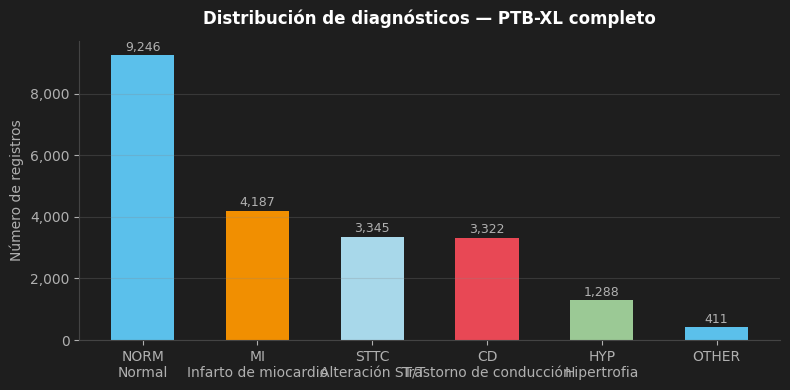

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Cargar tabla de declaraciones SCP para mapear código -> superclass
scp_info = pd.read_csv(os.path.join(DATA_DIR, 'scp_statements.csv'), index_col=0)

# Construir diccionario código -> superclase diagnóstica
scp_to_super = scp_info[scp_info['diagnostic'] == 1]['diagnostic_class'].to_dict()

def get_superclass(scp_str):
    """Devuelve la superclase diagnóstica más probable de un registro."""
    try:
        codes = ast.literal_eval(scp_str)  # convierte el string a dict
    except Exception:
        return 'UNKNOWN'
    # Filtrar solo los códigos diagnósticos y quedarse con el de mayor probabilidad
    diag = {k: v for k, v in codes.items() if k in scp_to_super}
    if not diag:
        return 'OTHER'
    best_code = max(diag, key=diag.get)
    return scp_to_super[best_code]

meta['superclass'] = meta['scp_codes'].apply(get_superclass)

# Distribución de superclases
counts = meta['superclass'].value_counts()

# Etiquetas completas para el gráfico
labels_full = {
    'NORM': 'NORM\nNormal',
    'MI':   'MI\nInfarto de miocardio',
    'STTC': 'STTC\nAlteración ST/T',
    'CD':   'CD\nTrastorno de conducción',
    'HYP':  'HYP\nHipertrofia'}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [labels_full.get(k, k) for k in counts.index],
    counts.values,
    color=['#5BC0EB', '#F18F01', '#A8D8EA', '#E84855', '#9BC995'],
    edgecolor='none',
    width=0.55)

# Etiqueta de cantidad sobre cada barra
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=9, color='#b0b0b0')

ax.set_title('Distribución de diagnósticos — PTB-XL completo', fontweight='bold', color='white', pad=12)
ax.set_ylabel('Número de registros', color='#b0b0b0')
ax.tick_params(colors='#b0b0b0')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')
ax.grid(axis='y', alpha=0.25, color='#888')
ax.set_facecolor('#1e1e1e')
fig.patch.set_facecolor('#1e1e1e')

plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB'>4. Carga de un par de señales</h2>
<p style='color:#b0b0b0'>Cada registro existe en dos versiones del mismo momento de medición. <code>wfdb.rdsamp()</code> devuelve una tupla: la señal como array NumPy y un objeto de metadatos del canal.</p>

In [11]:
# Usamos el primer ecg_id del dataset
ECG_ID = meta.index[0]
row = meta.loc[ECG_ID]

# Cargar versión de 100 Hz
path_lr = os.path.join(DATA_DIR, row['filename_lr'])
signal_lr, fields_lr = wfdb.rdsamp(path_lr)

# Cargar versión de 500 Hz
path_hr = os.path.join(DATA_DIR, row['filename_hr'])
signal_hr, fields_hr = wfdb.rdsamp(path_hr)

print(f'ECG ID seleccionado: {ECG_ID}')
print(f'Diagnóstico: {row["superclass"]}')
print()
print(f'Señal 100 Hz — shape: {signal_lr.shape}')
print(f'  eje 0 = muestras de tiempo ({signal_lr.shape[0]} pts = {signal_lr.shape[0]/100:.1f} s a 100 Hz)')
print(f'  eje 1 = derivaciones ({signal_lr.shape[1]} canales: {fields_lr["sig_name"]})')
print()
print(f'Señal 500 Hz — shape: {signal_hr.shape}')
print(f'  eje 0 = muestras de tiempo ({signal_hr.shape[0]} pts = {signal_hr.shape[0]/500:.1f} s a 500 Hz)')
print(f'  eje 1 = derivaciones ({signal_hr.shape[1]} canales)')

ECG ID seleccionado: 1
Diagnóstico: NORM

Señal 100 Hz — shape: (1000, 12)
  eje 0 = muestras de tiempo (1000 pts = 10.0 s a 100 Hz)
  eje 1 = derivaciones (12 canales: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'])

Señal 500 Hz — shape: (5000, 12)
  eje 0 = muestras de tiempo (5000 pts = 10.0 s a 500 Hz)
  eje 1 = derivaciones (12 canales)


<h2 style='color:#5BC0EB'>5. Visualización comparativa</h2>
<p style='color:#b0b0b0'>Graficamos la derivación II a ambas resoluciones. La derivación II (índice 1) es la más usada en clínica porque suele tener la mejor morfología del complejo QRS. El zoom sobre el primer QRS hace visible la diferencia real entre 10 puntos y 50 puntos en 100 ms.</p>

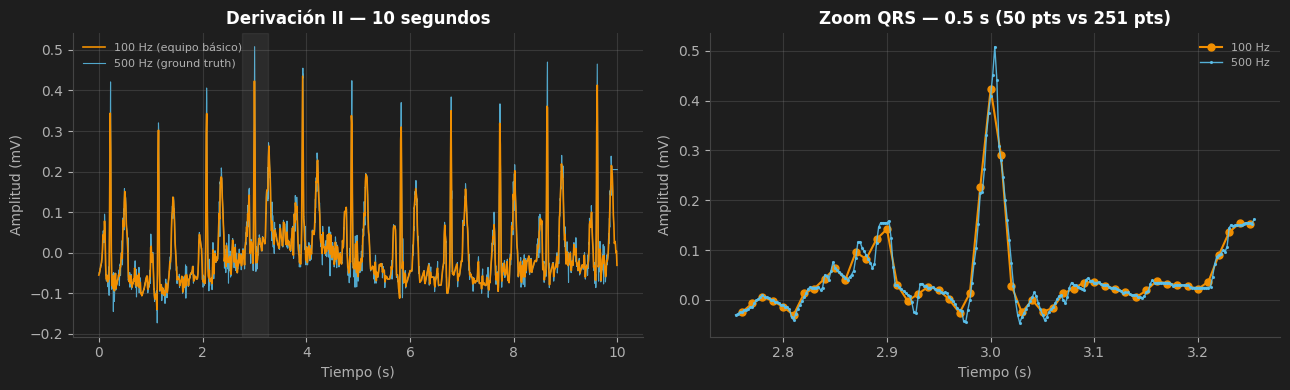

In [12]:
# Derivación II = índice 1 en el array (orden estándar: I, II, III, aVR, aVL, aVF, V1-V6)
LEAD = 1
LEAD_NAME = 'II'

# Ejes de tiempo en segundos para cada resolución
t_lr = np.arange(signal_lr.shape[0]) / 100
t_hr = np.arange(signal_hr.shape[0]) / 500

# Detectar el primer pico R (máximo global) en la señal de alta resolución
lead_hr = signal_hr[:, LEAD]
r_idx_hr = int(np.argmax(lead_hr))  # índice del pico R en muestras a 500 Hz
r_time = r_idx_hr / 500             # tiempo del pico R en segundos

# Ventana de zoom: 0.5 s centrada en el pico R
zoom_start = max(0, r_time - 0.25)
zoom_end   = min(10, r_time + 0.25)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#1e1e1e')

# Panel izquierdo: señal completa de 10 segundos
ax = axes[0]
ax.plot(t_lr, signal_lr[:, LEAD], color='#F18F01', lw=1.2, label='100 Hz (equipo básico)', zorder=2)
ax.plot(t_hr, lead_hr,            color='#5BC0EB', lw=0.8, alpha=0.85, label='500 Hz (ground truth)', zorder=1)
ax.axvspan(zoom_start, zoom_end, color='#ffffff', alpha=0.06)  # resaltar zona de zoom
ax.set_title(f'Derivación {LEAD_NAME} — 10 segundos', fontweight='bold', color='white')
ax.set_xlabel('Tiempo (s)', color='#b0b0b0')
ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)
ax.tick_params(colors='#b0b0b0')
ax.set_facecolor('#1e1e1e')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')
ax.grid(alpha=0.25, color='#888')

# Panel derecho: zoom de 0.5 s sobre el primer QRS
ax = axes[1]

# Filtrar muestras dentro de la ventana de zoom
mask_lr = (t_lr >= zoom_start) & (t_lr <= zoom_end)
mask_hr = (t_hr >= zoom_start) & (t_hr <= zoom_end)

ax.plot(
    t_lr[mask_lr], signal_lr[mask_lr, LEAD],
    color='#F18F01', lw=1.5, marker='o', ms=5, label='100 Hz')
ax.plot(
    t_hr[mask_hr], lead_hr[mask_hr],
    color='#5BC0EB', lw=1.0, marker='.', ms=2.5, alpha=0.9, label='500 Hz')

n_lr = mask_lr.sum()
n_hr = mask_hr.sum()
ax.set_title(
    f'Zoom QRS — {zoom_end - zoom_start:.1f} s ({n_lr} pts vs {n_hr} pts)',
    fontweight='bold', color='white')
ax.set_xlabel('Tiempo (s)', color='#b0b0b0')
ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)
ax.tick_params(colors='#b0b0b0')
ax.set_facecolor('#1e1e1e')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')
ax.grid(alpha=0.25, color='#888')

plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB'>6. Geometría por región fisiológica</h2>
<p style='color:#b0b0b0'>Un ciclo cardíaco tiene tres regiones con formas geométricas muy distintas. Las segmentamos automáticamente a partir del pico R, que es el punto de máxima amplitud y el más fácil de detectar.</p>

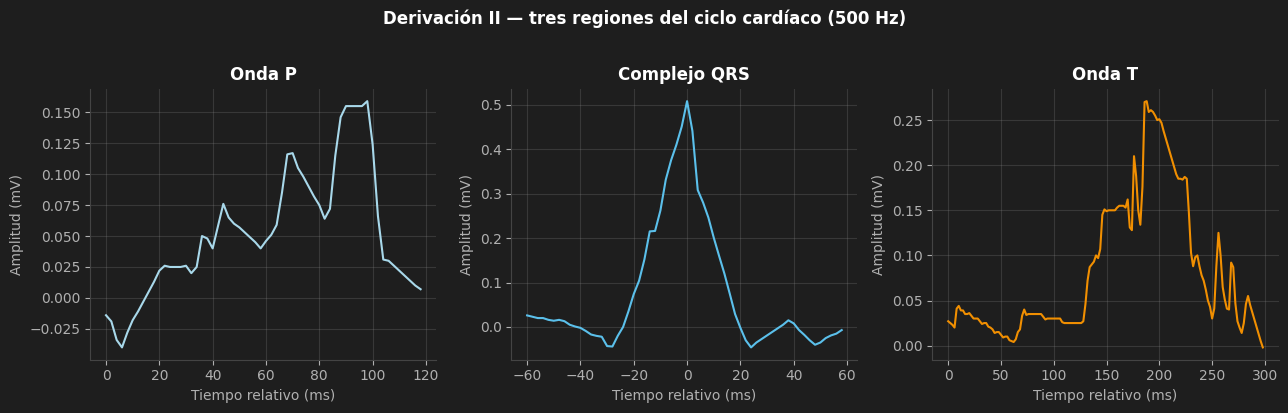

In [13]:
# Trabajamos en muestras (no segundos) para simplicidad de indexado
FS = 500  # frecuencia de muestreo de la señal de alta resolución

def ms_to_samples(ms, fs=500):
    return int(ms / 1000 * fs)

# Índice del pico R en la señal de alta resolución
r = r_idx_hr

# Ventanas fisiológicas relativas al pico R
# Onda P: antes del QRS, entre -200 ms y -80 ms del pico R
p_start = r - ms_to_samples(200)
p_end   = r - ms_to_samples(80)

# Complejo QRS: ventana simétrica de ±60 ms alrededor del pico R
q_start = r - ms_to_samples(60)
q_end   = r + ms_to_samples(60)

# Onda T: después del QRS, entre +80 ms y +380 ms del pico R
t_start = r + ms_to_samples(80)
t_end   = r + ms_to_samples(380)

# Asegurar que los índices sean válidos
n = len(lead_hr)
p_start, p_end  = max(0, p_start), min(n, p_end)
q_start, q_end  = max(0, q_start), min(n, q_end)
t_start, t_end  = max(0, t_start), min(n, t_end)

# Extraer segmentos
seg_p   = lead_hr[p_start:p_end]
seg_qrs = lead_hr[q_start:q_end]
seg_t   = lead_hr[t_start:t_end]

# Ejes de tiempo relativos en ms para cada segmento
t_p   = np.arange(len(seg_p))   * 1000 / FS
t_qrs = (np.arange(len(seg_qrs)) - ms_to_samples(60)) * 1000 / FS
t_t   = np.arange(len(seg_t))   * 1000 / FS

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor('#1e1e1e')

config = [
    (axes[0], t_p,   seg_p,   'Onda P',         '#A8D8EA'),
    (axes[1], t_qrs, seg_qrs, 'Complejo QRS',   '#5BC0EB'),
    (axes[2], t_t,   seg_t,   'Onda T',         '#F18F01')]

for ax, t_seg, sig, title, color in config:
    ax.plot(t_seg, sig, color=color, lw=1.5)
    ax.set_title(title, fontweight='bold', color='white')
    ax.set_xlabel('Tiempo relativo (ms)', color='#b0b0b0')
    ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')
    ax.tick_params(colors='#b0b0b0')
    ax.set_facecolor('#1e1e1e')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')
    ax.grid(alpha=0.25, color='#888')

plt.suptitle(
    f'Derivación {LEAD_NAME} — tres regiones del ciclo cardíaco (500 Hz)',
    fontweight='bold', color='white', y=1.02
)
plt.tight_layout()
plt.show()

<h3 style='color:#A8D8EA'>¿Por qué cada región pide un método distinto?</h3>
<p style='color:#b0b0b0'>
La <strong>onda P</strong> es suave, redondeada y de baja amplitud: una región de variación lenta sin picos abruptos, lo que la hace naturalmente compatible con un ajuste polinomial de grado bajo o una gaussiana amplia. El <strong>complejo QRS</strong> es el evento más breve y de mayor energía del ciclo: concentra el 80% de la amplitud en menos de 120 ms, con un pico R estrecho y flancos casi verticales que un polinomio de alto grado distorsionaría y que una gaussiana captura bien si el pico es limpio. La <strong>onda T</strong> tiene una geometría asimétrica —subida lenta, pico redondeado, bajada más rápida— con variabilidad local en la cola que el spline cúbico puede seguir de forma natural. Ningún método es óptimo para las tres: esa es la razón de ser del selector automático.
</p>

<h2 style='color:#5BC0EB'>7. Estadísticas del subset de 500 registros</h2>
<p style='color:#b0b0b0'>Una mirada rápida a quiénes son los pacientes de nuestro subset de exploración.</p>

In [14]:
# Reasignar superclass al subset
subset = meta.iloc[:500].copy()
subset['superclass'] = subset['scp_codes'].apply(get_superclass)

# Tabla de diagnósticos
diag_counts = subset['superclass'].value_counts().rename('N registros').to_frame()
diag_counts['%'] = (diag_counts['N registros'] / len(subset) * 100).round(1)

print('Distribución diagnóstica (subset 500 registros)')
print(diag_counts.to_string())
print()

# Rango de edades
ages = subset['age'].dropna()
print(f'Edad   min: {ages.min():.0f}  max: {ages.max():.0f}  media: {ages.mean():.1f}  mediana: {ages.median():.0f}')
print()

# Distribución de sexo
sex_map = {0: 'Masculino', 1: 'Femenino'}
sex_counts = subset['sex'].map(sex_map).value_counts()
print('Distribución de sexo')
print(sex_counts.to_string())

Distribución diagnóstica (subset 500 registros)
            N registros     %
superclass                   
NORM                293  58.6
STTC                 69  13.8
CD                   59  11.8
MI                   45   9.0
HYP                  23   4.6
OTHER                11   2.2

Edad   min: 17  max: 300  media: 54.0  mediana: 52

Distribución de sexo
sex
Femenino     250
Masculino    250


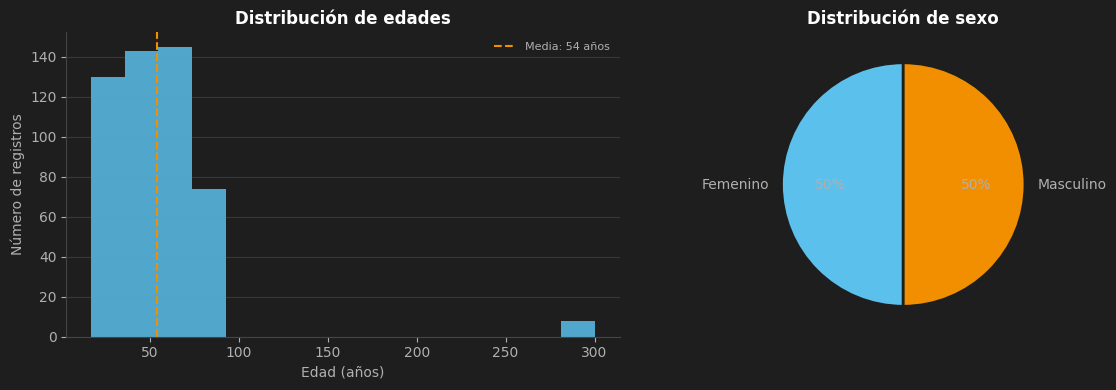

In [15]:
# Resumen visual: edad por diagnóstico
superclasses = subset['superclass'].unique()
colors_sc = ['#5BC0EB', '#F18F01', '#A8D8EA', '#E84855', '#9BC995']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1e1e1e')

# Histograma de edades
ax = axes[0]
ax.hist(ages, bins=15, color='#5BC0EB', edgecolor='none', alpha=0.85)
ax.axvline(ages.mean(), color='#F18F01', lw=1.5, linestyle='--', label=f'Media: {ages.mean():.0f} años')
ax.set_title('Distribución de edades', fontweight='bold', color='white')
ax.set_xlabel('Edad (años)', color='#b0b0b0')
ax.set_ylabel('Número de registros', color='#b0b0b0')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)
ax.tick_params(colors='#b0b0b0')
ax.set_facecolor('#1e1e1e')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')
ax.grid(axis='y', alpha=0.25, color='#888')

# Pie chart de sexo
ax = axes[1]
sex_vals = subset['sex'].map(sex_map).value_counts()
wedges, texts, autotexts = ax.pie(
    sex_vals.values,
    labels=sex_vals.index,
    autopct='%1.0f%%',
    colors=['#5BC0EB', '#F18F01'],
    startangle=90,
    wedgeprops={'edgecolor': '#1e1e1e', 'linewidth': 2})
for text in texts + autotexts:
    text.set_color('#b0b0b0')
ax.set_title('Distribución de sexo', fontweight='bold', color='white')
ax.set_facecolor('#1e1e1e')

plt.tight_layout()
plt.show()

<blockquote style='border-left:4px solid #F18F01; background:rgba(241,143,1,0.10); color:#e8c97a; padding:10px 14px; margin:8px 0'>
<strong>Próximo paso:</strong> con los datos cargados y la geometría por región identificada, el siguiente notebook construirá el pipeline de submuestreo controlado: toma la señal de 500 Hz, la reduce a 100 Hz de forma limpia (sin aliasing), y aplica los tres métodos de reconstrucción (polinomio, gaussianas, spline) sobre cada región fisiológica por separado.
</blockquote>